# Filtering TM/TR CDF plot (tvkern 0609)

Based on the 0604 tvkern notebook. This version reads the full camd9554n1 data pulled back to af309 and supports `nsampRatio/nsamp` result directories.


In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
DATA_FOLDERS = [
    Path('/astrum/home/hpchzy/code/data/20260609/camd9554n1/output_tvkern_filt/20260609-160902/'),
]

QUANTILE_DROP = 0.99
SAVE_FIG = True
OUT_DIR = Path('/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0609_tvkern')

TIMER_COLORS = {
    'cgt': '#ff7f0e',
    'clock_gettime': '#ff7f0e',
    'wtime': '#2ca02c',
    'mpi_wtime': '#2ca02c',
    'papi': '#d62728',
    'papix6': '#9467bd',
    'likwid': '#8c564b',
    'tsc': '#1f77b4',
    'tsc_fence': '#4f8dd3',
    'tsc_native': '#17becf',
}

TIMER_LABELS = {
    'tsc': 'TSC',
    'tsc_fence': 'TSC_Fence',
    'tsc_native': 'TSC_Native',
    'cgt': 'clock_gettime',
    'clock_gettime': 'clock_gettime',
    'wtime': 'MPI_Wtime',
    'mpi_wtime': 'MPI_Wtime',
    'papi': 'PAPI',
    'papix6': 'PAPIx6',
    'likwid': 'LIKWID',
}

KERNEL_LABELS = {'tvkern': 'Synthetic Timer-Variance Kernel'}
HOST_LABELS = {'camd9554n1': 'AMD EPYC 9554 n1', 'camd9554n2': 'AMD EPYC 9554 n2', 'c920bn3': 'Kunpeng 920B', 'cgnr6760pn2': 'Intel Xeon 6760P'}
OUT_DIR.mkdir(parents=True, exist_ok=True)


In [3]:
def parse_filt_dir(path):
    patterns = [
        r'(?P<kernel>.+)_(?P<timer>.+)_np(?P<np>\d+)_size(?P<size>\d+)_nsampRatio(?P<ratio>[0-9.]+)_nsamp(?P<nsamp>\d+)_filt$',
        r'(?P<kernel>.+)_(?P<timer>.+)_np(?P<np>\d+)_size(?P<size>\d+)_filt$',
    ]
    for pat in patterns:
        m = re.match(pat, path.name)
        if m:
            d = m.groupdict()
            d['np'] = int(d['np'])
            d['size'] = int(d['size'])
            d['ratio'] = float(d.get('ratio') or np.nan)
            d['nsamp'] = int(d.get('nsamp') or 0)
            return d
    return None


def host_from_data_folder(data_folder):
    parts = Path(data_folder).parts
    if 'data' in parts:
        i = parts.index('data')
        if len(parts) > i + 2:
            return parts[i + 2]
    return Path(data_folder).name


def timer_label(timer):
    return TIMER_LABELS.get(timer, timer.upper().replace('_', '-'))


def timer_sort_key(timer):
    order = ['tsc', 'tsc_fence', 'tsc_native', 'cgt', 'clock_gettime', 'wtime', 'mpi_wtime', 'papi', 'papix6', 'likwid']
    return (order.index(timer) if timer in order else len(order), timer)


def ecdf_xy(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    vals = np.sort(vals)
    if vals.size == 0:
        return vals, vals
    y = np.arange(1, vals.size + 1) / vals.size
    keep = y <= QUANTILE_DROP
    x = vals[keep]
    y = y[keep]
    if x.size:
        x = np.r_[x[0], x]
        y = np.r_[0.0, y]
    return x, y


def read_tm(tm_file):
    df = pd.read_csv(tm_file, header=None, names=['ns'])
    df['ns'] = pd.to_numeric(df['ns'], errors='coerce')
    return df['ns'].dropna().to_numpy()


def read_hist(hist_file):
    df = pd.read_csv(hist_file, header=None, names=['ns', 'prob'])
    df['ns'] = pd.to_numeric(df['ns'], errors='coerce')
    df['prob'] = pd.to_numeric(df['prob'], errors='coerce')
    df = df[np.isfinite(df['ns']) & np.isfinite(df['prob'])].copy()
    df = df[df['prob'] > 0]
    df.sort_values('ns', inplace=True)
    total = df['prob'].sum()
    if total > 0:
        df['prob'] = df['prob'] / total
    df['cdf'] = df['prob'].cumsum()
    df = df[df['cdf'] <= QUANTILE_DROP].copy()
    if not df.empty:
        first = pd.DataFrame({'ns': [df['ns'].iloc[0]], 'prob': [0.0], 'cdf': [0.0]})
        df = pd.concat([first, df], ignore_index=True)
    return df


def collect_entries(data_folder):
    rows = []
    data_folder = Path(data_folder)
    host = host_from_data_folder(data_folder)
    for tr_hist_file in sorted(data_folder.glob('*/tr_hist.csv')):
        filt_dir = tr_hist_file.parent
        meta = parse_filt_dir(filt_dir)
        if meta is None:
            continue
        tm_file = filt_dir / 'met.csv'
        tm_hist_file = filt_dir / 'tm_hist.csv'
        if not tm_file.exists():
            print(f'skip missing met.csv: {filt_dir}')
            continue
        rows.append({**meta, 'host': host, 'data_folder': data_folder, 'filt_dir': filt_dir, 'tm_file': tm_file, 'tm_hist_file': tm_hist_file, 'tr_hist_file': tr_hist_file})
    return pd.DataFrame(rows)


entries = pd.concat([collect_entries(p) for p in DATA_FOLDERS], ignore_index=True)
entries.sort_values(['host', 'kernel', 'np', 'size', 'ratio', 'timer'], inplace=True)
print(f'entries: {len(entries)}')
entries.head(20)


entries: 6


,kernel,timer,np,size,ratio,nsamp,host,data_folder,filt_dir,tm_file,tm_hist_file,tr_hist_file
0,tvkern,papi,64,512,0.5,11953,camd9554n1,/astrum/home/hpchzy/code/data/20260609/camd955...,/astrum/home/hpchzy/code/data/20260609/camd955...,/astrum/home/hpchzy/code/data/20260609/camd955...,/astrum/home/hpchzy/code/data/20260609/camd955...,/astrum/home/hpchzy/code/data/20260609/camd955...
4,tvkern,tsc,64,512,0.5,10056,camd9554n1,/astrum/home/hpchzy/code/data/20260609/camd955...,/astrum/home/hpchzy/code/data/20260609/camd955...,/astrum/home/hpchzy/code/data/20260609/camd955...,/astrum/home/hpchzy/code/data/20260609/camd955...,/astrum/home/hpchzy/code/data/20260609/camd955...
1,tvkern,papi,64,512,1.0,46878,camd9554n1,/astrum/home/hpchzy/code/data/20260609/camd955...,/astrum/home/hpchzy/code/data/20260609/camd955...,/astrum/home/hpchzy/code/data/20260609/camd955...,/astrum/home/hpchzy/code/data/20260609/camd955...,/astrum/home/hpchzy/code/data/20260609/camd955...
5,tvkern,tsc,64,512,1.0,24462,camd9554n1,/astrum/home/hpchzy/code/data/20260609/camd955...,/astrum/home/hpchzy/code/data/20260609/camd955...,/astrum/home/hpchzy/code/data/20260609/camd955...,/astrum/home/hpchzy/code/data/20260609/camd955...,/astrum/home/hpchzy/code/data/20260609/camd955...
2,tvkern_tsc,native,64,512,0.5,10087,camd9554n1,/astrum/home/hpchzy/code/data/20260609/camd955...,/astrum/home/hpchzy/code/data/20260609/camd955...,/astrum/home/hpchzy/code/data/20260609/camd955...,/astrum/home/hpchzy/code/data/20260609/camd955...,/astrum/home/hpchzy/code/data/20260609/camd955...
3,tvkern_tsc,native,64,512,1.0,28095,camd9554n1,/astrum/home/hpchzy/code/data/20260609/camd955...,/astrum/home/hpchzy/code/data/20260609/camd955...,/astrum/home/hpchzy/code/data/20260609/camd955...,/astrum/home/hpchzy/code/data/20260609/camd955...,/astrum/home/hpchzy/code/data/20260609/camd955...


# ER/EP/Wasserstein summary


In [4]:
def read_float_file(path):
    try:
        text = Path(path).read_text().strip()
        return float(text) if text else np.nan
    except FileNotFoundError:
        print(f'warning: missing {path}')
        return np.nan
    except ValueError:
        print(f'warning: invalid float in {path}')
        return np.nan


def wd_to_min(hist_file):
    df = read_hist(hist_file)
    if df.empty:
        return np.nan
    ns = df['ns'].to_numpy(dtype=float)
    pr = df['prob'].to_numpy(dtype=float)
    if pr.sum() <= 0:
        return np.nan
    return np.sum(np.abs(ns - ns.min()) * pr) / pr.sum()


summary_rows = []
for _, row in entries.iterrows():
    filt_folder = Path(row['filt_dir'])
    summary_rows.append({
        **row.to_dict(),
        'ep': read_float_file(filt_folder / 'ep.out'),
        'er': read_float_file(filt_folder / 'er.out'),
        'wd': read_float_file(filt_folder / 'wd.out'),
        'tm_wd_to_min': wd_to_min(filt_folder / 'tm_hist.csv'),
        'tr_wd_to_min': wd_to_min(filt_folder / 'tr_hist.csv'),
    })

df = pd.DataFrame(summary_rows).reset_index(drop=True)
df['timer_label'] = df['timer'].map(TIMER_LABELS).fillna(df['timer'])
df['kernel_label'] = df['kernel'].map(KERNEL_LABELS).fillna(df['kernel'])
df.sort_values(['host', 'kernel', 'np', 'size', 'ratio', 'timer'], inplace=True)
df[['host', 'kernel', 'timer', 'np', 'size', 'ratio', 'nsamp', 'ep', 'er', 'wd', 'tm_wd_to_min', 'tr_wd_to_min']].head(20)


,host,kernel,timer,np,size,ratio,nsamp,ep,er,wd,tm_wd_to_min,tr_wd_to_min
0,camd9554n1,tvkern,papi,64,512,0.5,11953,0.000141,0.001250,4.817085,27.469947,27.469943
1,camd9554n1,tvkern,tsc,64,512,0.5,10056,0.000000,0.001287,4.182915,14.548813,9.667038
2,camd9554n1,tvkern,papi,64,512,1.0,46878,0.000141,0.004767,18.369849,27.469947,27.469943
3,camd9554n1,tvkern,tsc,64,512,1.0,24462,0.000000,0.001136,3.690452,14.548813,9.768048
4,camd9554n1,tvkern_tsc,native,64,512,0.5,10087,0.000000,0.001058,3.469347,41.203048,9.407127
5,camd9554n1,tvkern_tsc,native,64,512,1.0,28095,0.094733,0.007622,24.989950,41.203048,25.124237


/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0609_tvkern/tvkern_summary_ratio0.5.png


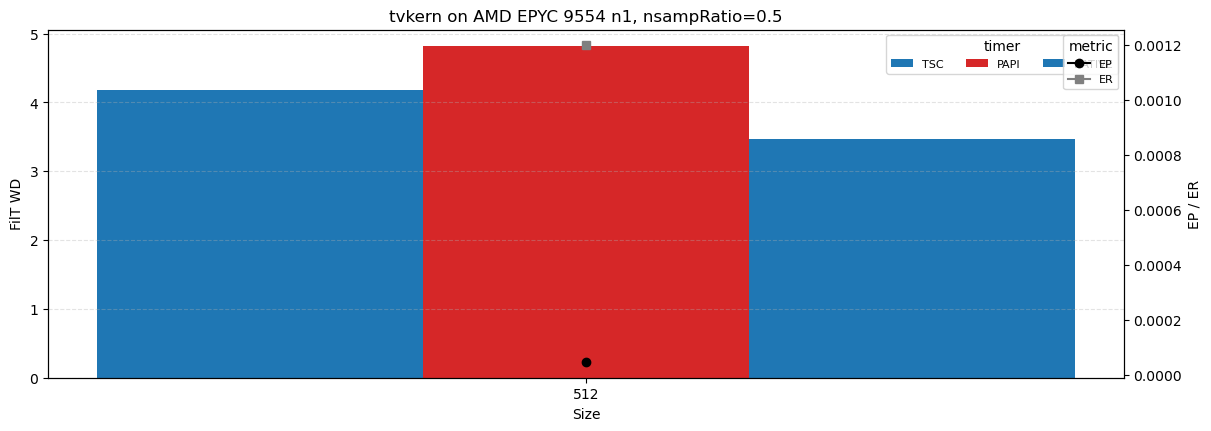

/astrum/home/hpchzy/code/TacVar/src/vkern/plots_0609_tvkern/tvkern_summary_ratio1.png


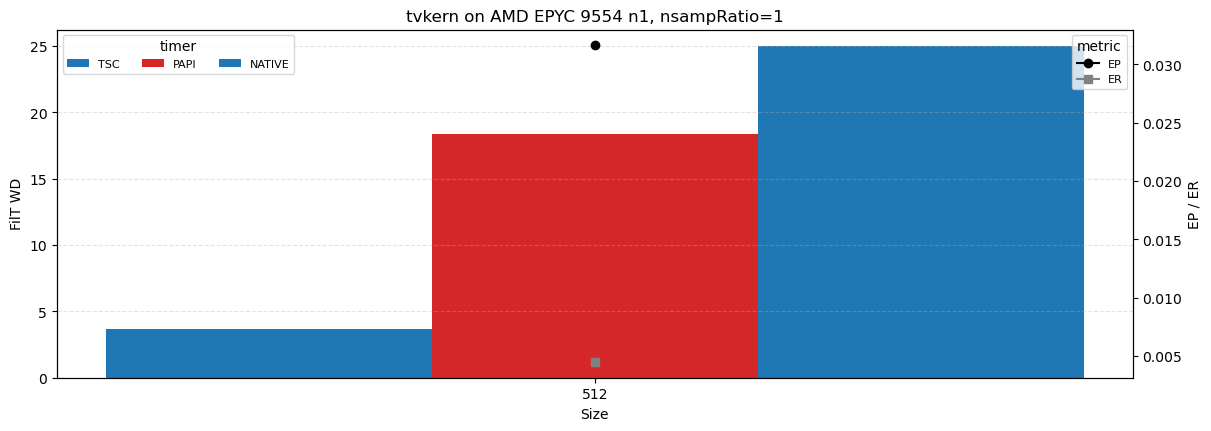

In [5]:
metric_bar = 'wd'
line_metrics = ['ep', 'er']

for ratio, ratio_df in df.groupby('ratio', sort=True):
    plot_df = ratio_df.copy()
    plot_df['size_str'] = plot_df['size'].astype(str)
    size_order = [str(x) for x in sorted(plot_df['size'].unique())]
    plot_df['size_str'] = pd.Categorical(plot_df['size_str'], categories=size_order, ordered=True)

    fig, ax1 = plt.subplots(figsize=(12, 4.2), constrained_layout=True)
    timers = sorted(plot_df['timer'].unique(), key=timer_sort_key)
    x = np.arange(len(size_order))
    width = 0.82 / max(len(timers), 1)

    for i, timer in enumerate(timers):
        sub = plot_df[plot_df['timer'] == timer].set_index('size_str').reindex(size_order)
        offset = (i - (len(timers) - 1) / 2) * width
        ax1.bar(x + offset, sub[metric_bar], width=width, label=timer_label(timer), color=TIMER_COLORS.get(timer))

    ax1.set_title(f'tvkern on {HOST_LABELS.get(plot_df.host.iloc[0], plot_df.host.iloc[0])}, nsampRatio={ratio:g}')
    ax1.set_xlabel('Size')
    ax1.set_ylabel('FilT WD')
    ax1.set_xticks(x)
    ax1.set_xticklabels(size_order)
    ax1.grid(axis='y', linestyle='--', alpha=0.35)
    ax1.legend(title='timer', ncol=3, fontsize=8)

    ax2 = ax1.twinx()
    line_df = plot_df.groupby('size_str', observed=True)[line_metrics].mean().reindex(size_order)
    ax2.plot(x, line_df['ep'], marker='o', label='EP', color='black')
    ax2.plot(x, line_df['er'], marker='s', label='ER', color='gray')
    ax2.set_ylabel('EP / ER')
    ax2.legend(title='metric', fontsize=8, loc='upper right')

    if SAVE_FIG:
        out = OUT_DIR / f'tvkern_summary_ratio{ratio:g}.png'
        fig.savefig(out, dpi=220, bbox_inches='tight')
        print(out)
    plt.show()


# TM/TR CDF plots


In [ ]:
# PLOT_SIZES = [0, 512, 4096, 8192]
PLOT_SIZES = [512]

if SAVE_FIG:
    OUT_DIR.mkdir(parents=True, exist_ok=True)

entries_plot = entries[entries['timer'] != 'papi']


for ratio in sorted(entries_plot['ratio'].dropna().unique()):
    for size in PLOT_SIZES:
        entries_plot = entries_plot[(entries_plot['ratio'] == ratio) & (entries_plot['size'] == size)]
        if entries_plot.empty:
            continue

        for (kernel, np_val), group in entries_plot.groupby(['kernel', 'np'], sort=True):
            group = group.sort_values('timer', key=lambda s: s.map(timer_sort_key))
            fig, ax = plt.subplots(figsize=(7.0, 4.6), constrained_layout=True)

            for _, row in group.iterrows():
                timer = row['timer']
                color = TIMER_COLORS.get(timer)
                label = timer_label(timer)
                tm_x, tm_y = ecdf_xy(read_tm(row['tm_file']))
                tr_df = read_hist(row['tr_hist_file'])

                ax.plot(tm_x, tm_y, label=f'{label}-TM', color=color, linestyle='--', linewidth=1.0)
                ax.step(tr_df['ns'], tr_df['cdf'], label=f'{label}-TR', color=color, linestyle='-', linewidth=1.0, where='post')

            host = group['host'].iloc[0]
            ax.set_title(f'{KERNEL_LABELS.get(kernel, kernel)} on {HOST_LABELS.get(host, host)}  np={np_val} size={size} ratio={ratio:g}')
            ax.set_xlabel('time (ns)')
            ax.set_ylabel('CDF')
            ax.set_ylim(0, QUANTILE_DROP)
            ax.grid(True, alpha=0.28)
            ax.legend(ncol=2, fontsize=8)

            if SAVE_FIG:
                out = OUT_DIR / f'{kernel}_np{np_val}_size{size}_ratio{ratio:g}_tm_tr.png'
                fig.savefig(out, dpi=220, bbox_inches='tight')
                print(out)
            plt.show()


In [7]:
(df.groupby(['ratio', 'size'])['timer']
   .nunique()
   .unstack('ratio')
   .fillna(0)
   .astype(int))


ratio,0.5,1.0
size,,
512,3,3
